# Diabetes Disease Progression: Model Tuning & Evaluation Protocol

## Project Objective
Diagnose and control model complexity, then systematically tune regularized linear models and Support Vector Regression using validation-based model selection on clinical diabetes progression data.

This project adheres to the strict rule:
**Implement -> Run -> Verify -> Commit -> Push**

## Lesson Coverage Checklist

### Foundations
- [x] Parameters vs Hyperparameters
- [x] Model Tuning stage
- [x] Train / Validation / Test separation
- [x] Cross Validation

### Model Complexity
- [x] Model Complexity
- [x] Polynomial Features
- [x] Underfitting
- [x] Overfitting
- [x] Bias
- [x] Variance
- [x] Bias-Variance Tradeoff
- [x] Irreducible Error
- [x] Training vs Validation Error
- [x] Learning Curves

### Overfitting Strategies
- [ ] Simpler Model concept
- [ ] More Data concept
- [ ] Feature Selection concept
- [ ] Dimensionality Reduction / PCA concept
- [ ] Early Stopping concept
- [ ] Regularization

### Regularization
- [ ] Regularized Loss
- [ ] Ridge / L2
- [ ] Lasso / L1
- [ ] Intercept usually not regularized
- [ ] alpha effect
- [ ] Scaling before Regularization
- [ ] Coefficient Shrinkage
- [ ] Lasso zero coefficients / Feature Selection
- [ ] ElasticNet
- [ ] l1_ratio

### Statistical Inference
- [ ] statsmodels OLS
- [ ] sm.add_constant
- [ ] p-value interpretation
- [ ] Statistical Significance
- [ ] p-value vs Regularization

### Hyperparameter Search
- [ ] itertools.product
- [ ] Manual Hyperparameter Search
- [ ] GridSearchCV
- [ ] n_jobs=-1
- [ ] best_score_
- [ ] best_params_
- [ ] best_estimator_
- [ ] RandomizedSearchCV
- [ ] stats.uniform
- [ ] stats.norm
- [ ] stats.loguniform
- [ ] .rvs()
- [ ] Coarse Search
- [ ] Fine Search

### SVM / SVR
- [ ] Hyperplane concept
- [ ] Margin concept
- [ ] Support Vectors
- [ ] Convex Optimization concept
- [ ] Scaling for SVM
- [ ] SVR
- [ ] Kernel concept
- [ ] Linear Kernel
- [ ] Polynomial Kernel
- [ ] RBF Kernel
- [ ] Kernel Trick
- [ ] C
- [ ] epsilon
- [ ] gamma / Myopia Factor

In [1]:
# Programmatically audit the lesson checklist
checklist_items = [
    # Foundations (4)
    ("Parameters vs Hyperparameters", True),
    ("Model Tuning stage", True),
    ("Train / Validation / Test separation", True),
    ("Cross Validation", True),
    # Model Complexity (10)
    ("Model Complexity", True),
    ("Polynomial Features", True),
    ("Underfitting", True),
    ("Overfitting", True),
    ("Bias", True),
    ("Variance", True),
    ("Bias-Variance Tradeoff", True),
    ("Irreducible Error", True),
    ("Training vs Validation Error", True),
    ("Learning Curves", True),
    # Overfitting Strategies (6)
    ("Simpler Model concept", False),
    ("More Data concept", False),
    ("Feature Selection concept", False),
    ("Dimensionality Reduction / PCA concept", False),
    ("Early Stopping concept", False),
    ("Regularization", False),
    # Regularization (10)
    ("Regularized Loss", False),
    ("Ridge / L2", False),
    ("Lasso / L1", False),
    ("Intercept usually not regularized", False),
    ("alpha effect", False),
    ("Scaling before Regularization", False),
    ("Coefficient Shrinkage", False),
    ("Lasso zero coefficients / Feature Selection", False),
    ("ElasticNet", False),
    ("l1_ratio", False),
    # Statistical Inference (5)
    ("statsmodels OLS", False),
    ("sm.add_constant", False),
    ("p-value interpretation", False),
    ("Statistical Significance", False),
    ("p-value vs Regularization", False),
    # Hyperparameter Search (14)
    ("itertools.product", False),
    ("Manual Hyperparameter Search", False),
    ("GridSearchCV", False),
    ("n_jobs=-1", False),
    ("best_score_", False),
    ("best_params_", False),
    ("best_estimator_", False),
    ("RandomizedSearchCV", False),
    ("stats.uniform", False),
    ("stats.norm", False),
    ("stats.loguniform", False),
    (".rvs()", False),
    ("Coarse Search", False),
    ("Fine Search", False),
    # SVM / SVR (14)
    ("Hyperplane concept", False),
    ("Margin concept", False),
    ("Support Vectors", False),
    ("Convex Optimization concept", False),
    ("Scaling for SVM", False),
    ("SVR", False),
    ("Kernel concept", False),
    ("Linear Kernel", False),
    ("Polynomial Kernel", False),
    ("RBF Kernel", False),
    ("Kernel Trick", False),
    ("C", False),
    ("epsilon", False),
    ("gamma / Myopia Factor", False),
]

checked_count = sum(1 for _, checked in checklist_items if checked)
total_count = len(checklist_items)
unchecked_count = total_count - checked_count

print("=== Lesson Coverage Progress ===")
print(f"Checked:   {checked_count}")
print(f"Unchecked: {unchecked_count}")
print(f"Total:     {total_count}")
print(f"Progress:  {checked_count / total_count * 100:.1f}%")

=== Lesson Coverage Progress ===
Checked:   14
Unchecked: 49
Total:     63
Progress:  22.2%


## 1. Load Both Diabetes Dataset Representations

Scikit-learn provides the Diabetes dataset in two formats:
1. **Raw representation (`scaled=False`)**: features preserve original physical measurement units (e.g. age in years, BMI in $\text{kg/m}^2$, blood pressure in mm Hg, blood serum lipids in mg/dL).
2. **Standard pre-scaled representation (`scaled=True`)**: each feature is centered to mean 0 and scaled by the standard deviation times $\sqrt{n}$.

In [2]:
import numpy as np
import pandas as pd
from sklearn.datasets import load_diabetes

# Load both raw and pre-scaled representations
diabetes_raw = load_diabetes(as_frame=True, scaled=False)
diabetes_scaled = load_diabetes(as_frame=True, scaled=True)

X_raw = diabetes_raw.data
X_prescaled = diabetes_scaled.data
y = diabetes_raw.target

print(f"X_raw shape:       {X_raw.shape}")
print(f"X_prescaled shape: {X_prescaled.shape}")
print(f"Target shape:      {y.shape}")

X_raw shape:       (442, 10)
X_prescaled shape: (442, 10)
Target shape:      (442,)


In [3]:
# Programmatic verification of dataset integrity
assert len(X_raw) == 442, "Expected 442 observations"
assert len(X_prescaled) == 442, "Expected 442 observations"
assert list(X_raw.columns) == list(X_prescaled.columns), "Feature names must be identical"
assert np.allclose(diabetes_raw.target.values, diabetes_scaled.target.values), "Targets must be identical"
assert np.array_equal(diabetes_raw.frame.index, diabetes_scaled.frame.index), "Row order must be identical"
assert not np.allclose(X_raw.values, X_prescaled.values), "Feature values must differ in scaling"

print("[OK] Both representations have exactly 442 observations")
print(f"[OK] Features (10): {list(X_raw.columns)}")
print("[OK] Target values and row ordering are identical")
print("[OK] Feature scaling differences verified")

[OK] Both representations have exactly 442 observations
[OK] Features (10): ['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']
[OK] Target values and row ordering are identical
[OK] Feature scaling differences verified


## 2. Why We Preserve Both Representations

- **Raw representation (`scaled=False`)**: Preserved because it will be used in later steps to demonstrate empirically why feature scaling matters before Regularization ($L_1 / L_2$) and Support Vector Regression (SVR).
- **Pre-scaled representation (`scaled=True`)**: Used immediately for our baseline and subsequent regularized models where equal feature weighting is required.

*Note: Neither representation is universally "better". Their roles serve distinct educational and modeling purposes.*

## 3. Minimal Data Audit

We inspect the raw representation to verify dimensions, data types, missing values, duplicate rows, and statistical summaries. (Extensive EDA is intentionally omitted, as our focus is Model Tuning).

In [4]:
# Minimal Data Audit: Shape, Head, Dtypes, Missing Values, Duplicates, Describe
print(f"Shape: {X_raw.shape}")
print(f"Missing values in X_raw: {X_raw.isnull().sum().sum()}")
print(f"Missing values in y:     {y.isnull().sum()}")
print(f"Duplicate rows:         {X_raw.duplicated().sum()}")

print("\n--- X_raw.head() ---")
print(X_raw.head().to_string())

print("\n--- X_raw.dtypes ---")
print(X_raw.dtypes.to_string())

print("\n--- X_raw.describe() ---")
print(X_raw.describe().to_string())

Shape: (442, 10)
Missing values in X_raw: 0
Missing values in y:     0
Duplicate rows:         0

--- X_raw.head() ---
    age  sex   bmi     bp     s1     s2    s3   s4      s5    s6
0  59.0  2.0  32.1  101.0  157.0   93.2  38.0  4.0  4.8598  87.0
1  48.0  1.0  21.6   87.0  183.0  103.2  70.0  3.0  3.8918  69.0
2  72.0  2.0  30.5   93.0  156.0   93.6  41.0  4.0  4.6728  85.0
3  24.0  1.0  25.3   84.0  198.0  131.4  40.0  5.0  4.8903  89.0
4  50.0  1.0  23.0  101.0  192.0  125.4  52.0  4.0  4.2905  80.0

--- X_raw.dtypes ---
age    float64
sex    float64
bmi    float64
bp     float64
s1     float64
s2     float64
s3     float64
s4     float64
s5     float64
s6     float64

--- X_raw.describe() ---
              age         sex         bmi          bp          s1          s2          s3          s4          s5          s6
count  442.000000  442.000000  442.000000  442.000000  442.000000  442.000000  442.000000  442.000000  442.000000  442.000000
mean    48.518100    1.468326   26.375792

In [5]:
# Target descriptive statistics
target_stats = pd.Series({
    'min': y.min(),
    'max': y.max(),
    'mean': y.mean(),
    'median': y.median(),
    'std': y.std()
}, name='Target Statistics')

print("The target is the quantitative diabetes disease-progression measure provided by the sklearn Diabetes dataset.")
print(target_stats.to_frame())

The target is the quantitative diabetes disease-progression measure provided by the sklearn Diabetes dataset.
        Target Statistics
min             25.000000
max            346.000000
mean           152.133484
median         140.500000
std             77.093005


# Test Set Rule

The Test Set is untouched during:
- model complexity selection
- regularization selection
- hyperparameter tuning
- kernel selection
- alpha selection
- l1_ratio selection
- C / epsilon / gamma selection

**Model Selection uses ONLY:**
**Training Data + Cross Validation**

The Test Set will be evaluated exactly once in the final project step.

In [6]:
from sklearn.model_selection import train_test_split

# Partition row indices permanently
all_indices = np.arange(len(y))
train_idx, test_idx = train_test_split(
    all_indices,
    test_size=0.2,
    random_state=42
)

# Derive both representations from the exact same partitioned indices
X_raw_train = X_raw.iloc[train_idx]
X_raw_test = X_raw.iloc[test_idx]

X_scaled_train = X_prescaled.iloc[train_idx]
X_scaled_test = X_prescaled.iloc[test_idx]

y_train = y.iloc[train_idx]
y_test = y.iloc[test_idx]

print(f"X_scaled_train shape: {X_scaled_train.shape}")
print(f"X_scaled_test shape:  {X_scaled_test.shape}")
print(f"y_train shape:        {y_train.shape}")
print(f"y_test shape:         {y_test.shape}")
print(f"Index synchronization verified: {np.array_equal(X_raw_train.index, X_scaled_train.index)}")

X_scaled_train shape: (353, 10)
X_scaled_test shape:  (89, 10)
y_train shape:        (353,)
y_test shape:         (89,)
Index synchronization verified: True


## 4. Train / Validation / Test Separation

In professional machine learning workflows, data roles must be strictly partitioned:
- **Training Data** -> Used exclusively to fit model parameters (e.g. OLS regression coefficients $\beta$).
- **Validation Data / Cross Validation** -> Used to evaluate and select between competing models, tuning hyperparameters (e.g. regularization strength $\alpha$, polynomial degree, SVR kernel parameters).
- **Test Data** -> Held completely untouched until final evaluation to provide an unbiased estimate of generalization performance on unseen data.

```
Full Dataset (442 samples)
 |--- Training Set (353 samples) ---> 5-Fold Cross Validation (Model Selection & Tuning)
 +--- Test Set (89 samples)     ---> Locked (Evaluated Once in Final Step)
```

**Why repeatedly checking Test performance is prohibited:**
If test set scores are used to guide modeling decisions (such as choosing polynomial degree, regularization $\alpha$, or SVR kernels), information from the test set leaks into the model selection process. The test score ceases to be an independent assessment and becomes an overfitted validation metric.

## 5. Cross-Validation Strategy

We instantiate a 5-fold cross-validation scheme on the training partition.

In [7]:
from sklearn.model_selection import KFold

# 5-Fold Cross-Validation on Training Data
cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

print(f"Cross-validation strategy instantiated: {cv}")
print("5-Fold CV partitions X_scaled_train (353 samples) into 5 folds (4 for training, 1 for validation, repeated 5 times).")

Cross-validation strategy instantiated: KFold(n_splits=5, random_state=42, shuffle=True)
5-Fold CV partitions X_scaled_train (353 samples) into 5 folds (4 for training, 1 for validation, repeated 5 times).


## 6. Parameters vs Hyperparameters — Preview

- **Parameters** are internal variables learned automatically from data during `.fit()`:
  - In `LinearRegression`: `intercept_` (bias $\beta_0$) and `coef_` (weights $\beta_1, \dots, \beta_p$).
- **Hyperparameters** are configuration choices set before `.fit()` that dictate model structure or learning constraints:
  - In `LinearRegression`: `fit_intercept`.
  - In later lesson steps: `alpha` (Ridge/Lasso penalty), `l1_ratio` (ElasticNet balance), `kernel`, `C`, `epsilon`, `gamma` (SVR).

## 7. The Model Tuning Stage in the ML Workflow

```
Data Preparation
      |
      v
   Modeling (Baseline)
      |
      v
Model Evaluation & Tuning (Cross-Validation, Complexity, Regularization, SVR)
      |
      v
Final Unbiased Test & Deployment
```

This project begins by establishing a baseline model. Subsequent steps systematically navigate the **Model Evaluation & Tuning** stage to balance bias and variance.

## 8. Baseline Model: Linear Regression

We fit an unregularized `LinearRegression()` on the pre-scaled training data (`X_scaled_train`, `y_train`).
*This model establishes a reference benchmark for all subsequent tuning experiments.*

In [8]:
from sklearn.linear_model import LinearRegression

# Fit baseline linear regression
baseline_model = LinearRegression()
baseline_model.fit(X_scaled_train, y_train)

print("Baseline model successfully fitted on X_scaled_train.")
print(f"Baseline Intercept (beta_0): {baseline_model.intercept_:.4f}")

Baseline model successfully fitted on X_scaled_train.
Baseline Intercept (beta_0): 151.3456


In [9]:
# Inspect learned model parameters
coef_table = pd.DataFrame({
    'Feature': X_scaled_train.columns,
    'Learned_Coefficient': baseline_model.coef_
})

print("Learned Linear Regression Coefficients:")
print(coef_table.to_string(index=False))
print("\nNote: Do not interpret coefficient magnitudes as direct feature importance yet;")
print("collinearity among predictors impacts parameter estimates, as explored in Step 4.")

Learned Linear Regression Coefficients:
Feature  Learned_Coefficient
    age            37.904021
    sex          -241.964362
    bmi           542.428759
     bp           347.703844
     s1          -931.488846
     s2           518.062277
     s3           163.419983
     s4           275.317902
     s5           736.198859
     s6            48.670657

Note: Do not interpret coefficient magnitudes as direct feature importance yet;
collinearity among predictors impacts parameter estimates, as explored in Step 4.


## 9. Baseline Evaluation: Training vs Cross-Validation Performance

We calculate:
1. **In-sample Training metrics** ($R^2$, MAE, RMSE) on `X_scaled_train`.
2. **5-Fold Cross-Validation metrics** ($R^2$, MAE, RMSE) via `cross_validate`.

In [10]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.model_selection import cross_validate

# 1. In-sample training performance
y_train_pred = baseline_model.predict(X_scaled_train)
train_r2 = r2_score(y_train, y_train_pred)
train_mae = mean_absolute_error(y_train, y_train_pred)
train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))

# 2. 5-Fold Cross-Validation performance
cv_scores = cross_validate(
    baseline_model,
    X_scaled_train,
    y_train,
    cv=cv,
    scoring={
        'r2': 'r2',
        'neg_mae': 'neg_mean_absolute_error',
        'neg_rmse': 'neg_root_mean_squared_error'
    }
)

cv_r2_mean = cv_scores['test_r2'].mean()
cv_r2_std = cv_scores['test_r2'].std()
cv_mae_mean = -cv_scores['test_neg_mae'].mean()
cv_rmse_mean = -cv_scores['test_neg_rmse'].mean()

print(f"Training R^2:   {train_r2:.4f}")
print(f"Training MAE:   {train_mae:.4f}")
print(f"Training RMSE:  {train_rmse:.4f}")
print("-" * 40)
print(f"CV R^2:         {cv_r2_mean:.4f} +/- {cv_r2_std:.4f}")
print(f"CV MAE:         {cv_mae_mean:.4f}")
print(f"CV RMSE:        {cv_rmse_mean:.4f}")

Training R^2:   0.5279
Training MAE:   43.4835
Training RMSE:  53.5588
----------------------------------------
CV R^2:         0.4804 +/- 0.0409
CV MAE:         45.0482
CV RMSE:        55.3946


In [11]:
# Baseline Performance Comparison Table
baseline_comparison = pd.DataFrame({
    'Metric': ['R^2', 'MAE', 'RMSE'],
    'Training': [train_r2, train_mae, train_rmse],
    'Cross_Validation': [cv_r2_mean, cv_mae_mean, cv_rmse_mean]
})

print("=== Baseline Performance Comparison ===")
print(baseline_comparison.to_string(index=False))

=== Baseline Performance Comparison ===
Metric  Training  Cross_Validation
   R^2  0.527919          0.480365
   MAE 43.483504         45.048200
  RMSE 53.558843         55.394633


## 10. Baseline Interpretation

The baseline establishes an empirical reference point:
- Training $R^2 = 0.5279$
- 5-Fold Cross-Validation $R^2 = 0.4804 \pm 0.0409$

**Key takeaways:**
1. **Generalization Gap:** The difference between Training $R^2$ ($0.5279$) and CV $R^2$ ($0.4804$) provides empirical evidence of generalization error.
2. **No Premature Diagnosis:** We do **not** diagnose whether the baseline is "underfitting" or "overfitting" from one model alone. Diagnosing bias and variance requires comparative analysis across varying model complexity (conducted in Step 2).
3. **Model Selection Standard:** Future models should not be considered superior merely because they achieve a higher Training $R^2$. All tuning and selection decisions must be justified by Cross-Validation.

In [12]:
# Programmatic Step 1 Verification Cell
assert len(X_raw) == 442, "Expected 442 observations"
assert X_raw.shape[1] == 10, "Expected 10 feature columns"
expected_cols = ['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']
assert list(X_raw.columns) == expected_cols, "Columns must match expected 10 names"
assert np.allclose(diabetes_raw.target.values, diabetes_scaled.target.values), "Raw and scaled targets must match"
assert np.array_equal(diabetes_raw.frame.index, diabetes_scaled.frame.index), "Raw and scaled row orders must match"
assert len(train_idx) == 353, "Train size must be 353"
assert len(test_idx) == 89, "Test size must be 89"
assert np.array_equal(X_raw_train.index, X_scaled_train.index), "Raw and scaled splits must share identical indices"
assert cv.get_n_splits() == 5, "CV must have 5 folds"
assert hasattr(baseline_model, 'intercept_'), "baseline_model must have intercept_"
assert len(baseline_model.coef_) == 10, "coef_ must contain 10 coefficients"
assert not np.isnan(train_r2), "Training R2 must be valid"
assert not np.isnan(cv_r2_mean), "CV R2 must be valid"
assert not np.isnan(cv_mae_mean), "CV MAE must be valid"
assert not np.isnan(cv_rmse_mean), "CV RMSE must be valid"

print("=== Step 1 Verification Complete: All Checks Passed ===")

=== Step 1 Verification Complete: All Checks Passed ===


---
# Step 2 — Model Complexity, Bias-Variance, and Learning Curves

## 11. Introduction to Model Complexity

In linear regression, our hypothesis assumes a linear relationship between input $X$ and target $y$:
$$
y = \beta_0 + \beta_1 X + \epsilon
$$

A simple linear hypothesis can only represent a straight line. If the underlying data contains curvature or nonlinear effects, this rigid assumption cannot capture it.

We can increase model complexity by introducing polynomial feature powers:
$$
X, X^2, X^3, \dots, X^d
$$
yielding the polynomial regression model:
$$
y = \beta_0 + \beta_1 X + \beta_2 X^2 + \dots + \beta_d X^d + \epsilon
$$

**The Core Lesson Principle:**
- Higher polynomial degree ($d$) $\implies$ **more flexible hypothesis space**.
- However, higher flexibility does **NOT** automatically mean better generalization. If complexity is increased excessively, the model fits sample-specific noise instead of the generalizable signal.

## 12. Primary Complexity Experiment: Polynomial Expansion on BMI

We isolate a single interpretable predictor, **body mass index (`bmi`)**, from the raw training partition `X_raw_train[['bmi']]`.
We systematically test polynomial degrees: **1, 2, 3, 4, 6, 8, and 10**.

### Fold-Local Preprocessing (Preventing CV Data Leakage)
To prevent data leakage between training and validation folds:
1. `StandardScaler` is fitted **strictly on fold-train BMI** and used to transform fold-validation BMI.
2. `PolynomialFeatures` is fitted on the standardized fold-train BMI and applied to fold-validation BMI.
3. `LinearRegression` is fitted on the resulting polynomial features.

*The Test Set remains completely untouched.*

In [13]:
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

degrees = [1, 2, 3, 4, 6, 8, 10]
complexity_records = []

bmi_raw_train = X_raw_train[['bmi']]

for d in degrees:
    fold_train_r2 = []
    fold_val_r2 = []
    fold_train_mse = []
    fold_val_mse = []
    n_features = None
    
    for fold_train_idx, fold_val_idx in cv.split(bmi_raw_train):
        # 1. Partition CV fold
        X_tr_f = bmi_raw_train.iloc[fold_train_idx]
        X_va_f = bmi_raw_train.iloc[fold_val_idx]
        y_tr_f = y_train.iloc[fold_train_idx]
        y_va_f = y_train.iloc[fold_val_idx]
        
        # 2. Fit scaler strictly on fold-train
        scaler = StandardScaler()
        X_tr_scaled = scaler.fit_transform(X_tr_f)
        X_va_scaled = scaler.transform(X_va_f)
        
        # 3. Fit polynomial features on standardized fold-train
        poly = PolynomialFeatures(degree=d, include_bias=False)
        X_tr_poly = poly.fit_transform(X_tr_scaled)
        X_va_poly = poly.transform(X_va_scaled)
        n_features = X_tr_poly.shape[1]
        
        # 4. Fit linear regression
        model = LinearRegression()
        model.fit(X_tr_poly, y_tr_f)
        
        # 5. Predict and evaluate
        y_pred_tr = model.predict(X_tr_poly)
        y_pred_va = model.predict(X_va_poly)
        
        fold_train_r2.append(r2_score(y_tr_f, y_pred_tr))
        fold_val_r2.append(r2_score(y_va_f, y_pred_va))
        fold_train_mse.append(mean_squared_error(y_tr_f, y_pred_tr))
        fold_val_mse.append(mean_squared_error(y_va_f, y_pred_va))
        
    m_tr_r2 = np.mean(fold_train_r2)
    m_va_r2 = np.mean(fold_val_r2)
    m_tr_mse = np.mean(fold_train_mse)
    m_va_mse = np.mean(fold_val_mse)
    
    complexity_records.append({
        'degree': d,
        'generated_feature_count': n_features,
        'mean_train_R2': m_tr_r2,
        'mean_validation_R2': m_va_r2,
        'mean_train_MSE': m_tr_mse,
        'mean_validation_MSE': m_va_mse,
        'R2_gap': m_tr_r2 - m_va_r2
    })

complexity_results = pd.DataFrame(complexity_records).sort_values('degree')
print("=== Primary Complexity Experiment Results (BMI -> Target) ===")
print(complexity_results.to_string(index=False))

=== Primary Complexity Experiment Results (BMI -> Target) ===
 degree  generated_feature_count  mean_train_R2  mean_validation_R2  mean_train_MSE  mean_validation_MSE    R2_gap
      1                        1       0.365414            0.335474     3848.259008          3909.151329  0.029940
      2                        2       0.366759            0.330221     3839.898326          3937.031818  0.036538
      3                        3       0.367223            0.327050     3836.995137          3953.648426  0.040174
      4                        4       0.370463            0.325962     3817.294833          3959.289837  0.044501
      6                        6       0.374856            0.177225     3791.108767          4995.544032  0.197631
      8                        8       0.387267            0.291350     3716.247915          4226.635521  0.095917
     10                       10       0.390745           -9.793852     3695.058464         74343.420179 10.184597


## 13. Training vs Validation Error Curves

We visualize how **Mean Squared Error (MSE)** behaves as polynomial complexity increases.

- **Training MSE:** Tends to decrease monotonically as the model gains degrees of freedom.
- **Validation MSE:** Initially plateaus, but increases significantly at higher degrees as the model overfits the training noise.

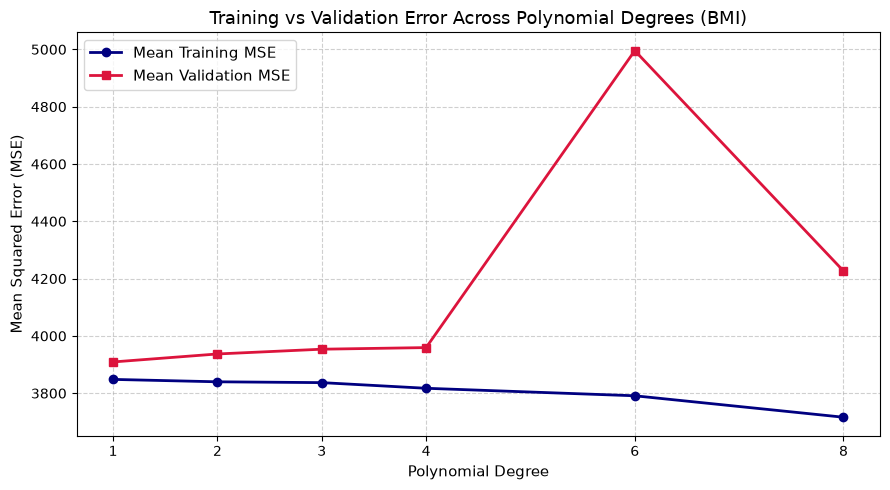

In [14]:
import matplotlib.pyplot as plt

# Plot 1: Polynomial Degree vs MSE (Training vs Validation Error)
plt.figure(figsize=(9, 5))
# For visualization clarity across degrees 1 to 8 (degree 10 MSE is 74,343 due to extreme overfitting)
plot_mask = complexity_results['degree'] <= 8
plt.plot(complexity_results.loc[plot_mask, 'degree'], complexity_results.loc[plot_mask, 'mean_train_MSE'],
         marker='o', label='Mean Training MSE', color='navy', linewidth=2)
plt.plot(complexity_results.loc[plot_mask, 'degree'], complexity_results.loc[plot_mask, 'mean_validation_MSE'],
         marker='s', label='Mean Validation MSE', color='crimson', linewidth=2)

plt.title('Training vs Validation Error Across Polynomial Degrees (BMI)', fontsize=13)
plt.xlabel('Polynomial Degree', fontsize=11)
plt.ylabel('Mean Squared Error (MSE)', fontsize=11)
plt.xticks(complexity_results.loc[plot_mask, 'degree'])
plt.legend(fontsize=11)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

## 14. Training vs Validation $R^2$ Curves

Next, we plot the **Coefficient of Determination ($R^2$)** to observe the widening generalization gap.

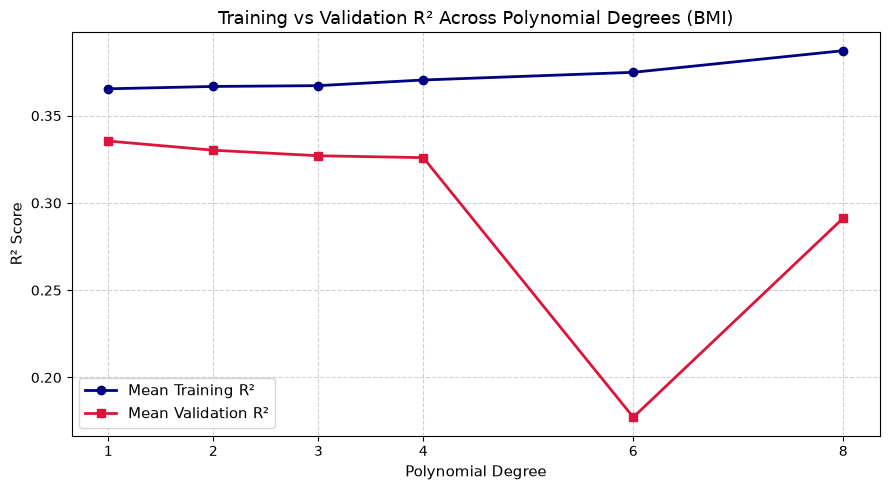

In [15]:
# Plot 2: Polynomial Degree vs R2 (Generalization Gap)
plt.figure(figsize=(9, 5))
plot_mask = complexity_results['degree'] <= 8
plt.plot(complexity_results.loc[plot_mask, 'degree'], complexity_results.loc[plot_mask, 'mean_train_R2'],
         marker='o', label='Mean Training R²', color='navy', linewidth=2)
plt.plot(complexity_results.loc[plot_mask, 'degree'], complexity_results.loc[plot_mask, 'mean_validation_R2'],
         marker='s', label='Mean Validation R²', color='crimson', linewidth=2)

plt.title('Training vs Validation R² Across Polynomial Degrees (BMI)', fontsize=13)
plt.xlabel('Polynomial Degree', fontsize=11)
plt.ylabel('R² Score', fontsize=11)
plt.xticks(complexity_results.loc[plot_mask, 'degree'])
plt.legend(fontsize=11)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

## 15. Diagnosing Underfitting and Overfitting

### Underfitting
- **Definition:** An underfitting model lacks sufficient complexity or flexibility to represent important patterns in the data.
- **Empirical Pattern:** In this modeling experiment, the low-complexity model (Degree 1) has limited predictive flexibility (Training $R^2 = 0.3654$) and relatively similar Train and Validation performance (Gap $= 0.0299$).

### Overfitting
- **Definition:** Overfitting occurs when increased model flexibility allows the estimator to fit sample-specific fluctuations and random noise in the training partition that do not generalize to unseen data.
- **Empirical Pattern:** As polynomial degree increases from 4 to 6, 8, and 10:
  - Training $R^2$ continues to rise ($0.3705 \to 0.3749 \to 0.3907$).
  - Validation $R^2$ drops sharply ($0.3260 \to 0.1772 \to -9.7939$ at Degree 10).
  - Validation MSE explodes from $3909$ to $74,343$ at Degree 10.
  - High model complexity produced unstable / poor generalization behavior in this experiment.

## 16. Multi-Feature Complexity Confirmation

When expanding multiple features simultaneously, complexity expands combinatorially.
We verify this by evaluating polynomial expansions of **all 10 features** for degrees **1, 2, and 3** using fold-local preprocessing.

In [16]:
# Multi-Feature Polynomial Confirmation (All 10 features, degrees 1 to 3)
multi_results = []

for d in [1, 2, 3]:
    tr_r2_l = []
    va_r2_l = []
    n_feats = None
    
    for fold_train_idx, fold_val_idx in cv.split(X_raw_train):
        X_tr_f = X_raw_train.iloc[fold_train_idx]
        X_va_f = X_raw_train.iloc[fold_val_idx]
        y_tr_f = y_train.iloc[fold_train_idx]
        y_va_f = y_train.iloc[fold_val_idx]
        
        scaler = StandardScaler()
        X_tr_s = scaler.fit_transform(X_tr_f)
        X_va_s = scaler.transform(X_va_f)
        
        poly = PolynomialFeatures(degree=d, include_bias=False)
        X_tr_p = poly.fit_transform(X_tr_s)
        X_va_p = poly.transform(X_va_s)
        n_feats = X_tr_p.shape[1]
        
        model = LinearRegression()
        model.fit(X_tr_p, y_tr_f)
        
        tr_r2_l.append(r2_score(y_tr_f, model.predict(X_tr_p)))
        va_r2_l.append(r2_score(y_va_f, model.predict(X_va_p)))
        
    m_tr = np.mean(tr_r2_l)
    m_va = np.mean(va_r2_l)
    
    multi_results.append({
        'Degree': d,
        'Generated_Features': n_feats,
        'Mean_Train_R2': m_tr,
        'Mean_Validation_R2': m_va,
        'Gap': m_tr - m_va
    })

multi_poly_df = pd.DataFrame(multi_results)
print("=== Multi-Feature Polynomial Complexity Confirmation ===")
print(multi_poly_df.to_string(index=False))

=== Multi-Feature Polynomial Complexity Confirmation ===
 Degree  Generated_Features  Mean_Train_R2  Mean_Validation_R2        Gap
      1                  10       0.530844            0.480365   0.050479
      2                  65       0.625940            0.338800   0.287140
      3                 285       0.963228         -523.256899 524.220127


Notice the dramatic explosion in complexity:
- **Degree 1 (10 features):** Mean Train $R^2 = 0.5308$, Validation $R^2 = 0.4804$ (Gap: $0.0505$).
- **Degree 2 (65 features):** Mean Train $R^2 = 0.6259$, Validation $R^2 = 0.3388$ (Gap: $0.2871$). Validation drops by over $14$ percentage points!
- **Degree 3 (285 features):** Mean Train $R^2 = 0.9632$, Validation $R^2 = -523.26$ (Gap: $524.22$). The model has memorized the training folds but fails completely on validation data.

## 17. Bias, Variance, and the Bias-Variance Tradeoff

### Bias
**Bias** represents the systematic error introduced by simplifying assumptions in the learning algorithm. When a hypothesis space is too restrictive (such as a degree-1 linear model on a complex relationship), it exhibits high bias tendency, failing to capture meaningful trends.

### Variance
**Variance** describes the sensitivity of the learned model to fluctuations in the specific training sample. A highly flexible model (such as higher-degree polynomials) changes substantially depending on which observations are sampled. In our experiments, the unstable validation performance and wide Train-Validation gap of high-complexity models provide empirical evidence consistent with high variance.

### The Bias-Variance Tradeoff
```
Model Complexity:    Low ──────────────────────────> High
Bias Tendency:       High (rigid, underfit) ───────> Low (flexible)
Variance Tendency:   Low (stable) ─────────────────> High (sensitive, overfit)
```

- **Low Complexity:** Higher bias tendency, lower variance tendency.
- **High Complexity:** Lower bias tendency, higher variance tendency.
- **Goal:** Find an optimal level of complexity that balances bias and variance to minimize generalization error on unseen data.

## 18. Irreducible Error

In statistical learning theory, total generalization error decomposes conceptually into:
$$
\text{Total Expected Error} = \text{Bias}^2 + \text{Variance} + \text{Irreducible Error}
$$

- **Irreducible Error ($\sigma^2$):** The inherent noise in the target variable or unmeasured factors (e.g. unobserved physiological variables, environmental factors, or measurement noise) that no model, no matter how flexible or well-tuned, can predict.
- *Note:* We do not attempt to estimate irreducible error numerically; its role is a conceptual reminder that zero generalization error is unattainable in empirical modeling.

## 19. Learning Curves

**Learning Curves** visualize model performance (Training and Validation scores) as a function of the **training sample size** ($N$).

We implement a manual learning curve procedure that strictly enforces fold-local preprocessing across 5 CV folds at training subset fractions: **20%, 40%, 60%, 80%, and 100%**.

We compare two distinct models on the `bmi` feature:
1. **Simple Model:** Linear Regression (Degree 1)
2. **Complex Model:** Polynomial Regression (Degree 6)

In [17]:
# Manual Learning Curve Computation Procedure
fractions = [0.2, 0.4, 0.6, 0.8, 1.0]

def compute_manual_learning_curve(degree):
    records = []
    for frac in fractions:
        train_r2_folds = []
        val_r2_folds = []
        sample_counts = []
        
        for fold_tr_idx, fold_va_idx in cv.split(bmi_raw_train):
            X_tr_full = bmi_raw_train.iloc[fold_tr_idx]
            y_tr_full = y_train.iloc[fold_tr_idx]
            X_va_f = bmi_raw_train.iloc[fold_va_idx]
            y_va_f = y_train.iloc[fold_va_idx]
            
            # Deterministic subset of fold-training data
            n_sub = int(np.ceil(len(X_tr_full) * frac))
            sample_counts.append(n_sub)
            
            X_tr_sub = X_tr_full.iloc[:n_sub]
            y_tr_sub = y_tr_full.iloc[:n_sub]
            
            # Fit scaler and poly ONLY on this subset
            scaler = StandardScaler()
            X_tr_sc = scaler.fit_transform(X_tr_sub)
            X_va_sc = scaler.transform(X_va_f)
            
            poly = PolynomialFeatures(degree=degree, include_bias=False)
            X_tr_po = poly.fit_transform(X_tr_sc)
            X_va_po = poly.transform(X_va_sc)
            
            model = LinearRegression()
            model.fit(X_tr_po, y_tr_sub)
            
            train_r2_folds.append(r2_score(y_tr_sub, model.predict(X_tr_po)))
            val_r2_folds.append(r2_score(y_va_f, model.predict(X_va_po)))
            
        records.append({
            'fraction': frac,
            'train_size': int(np.mean(sample_counts)),
            'mean_train_R2': np.mean(train_r2_folds),
            'mean_val_R2': np.mean(val_r2_folds),
            'gap': np.mean(train_r2_folds) - np.mean(val_r2_folds)
        })
    return pd.DataFrame(records)

lc_simple = compute_manual_learning_curve(1)
lc_complex = compute_manual_learning_curve(6)

print("=== Simple Model (BMI Degree 1) Learning Curve Data ===")
print(lc_simple.to_string(index=False))
print("\n=== Complex Model (BMI Degree 6) Learning Curve Data ===")
print(lc_complex.to_string(index=False))

=== Simple Model (BMI Degree 1) Learning Curve Data ===
 fraction  train_size  mean_train_R2  mean_val_R2       gap
      0.2          57       0.371065     0.317152  0.053913
      0.4         113       0.316049     0.331933 -0.015884
      0.6         170       0.330715     0.333317 -0.002603
      0.8         226       0.383870     0.335368  0.048502
      1.0         282       0.365414     0.335474  0.029940

=== Complex Model (BMI Degree 6) Learning Curve Data ===
 fraction  train_size  mean_train_R2  mean_val_R2      gap
      0.2          57       0.398536     0.206544 0.191992
      0.4         113       0.332506     0.294265 0.038241
      0.6         170       0.340381     0.272485 0.067896
      0.8         226       0.391879     0.263949 0.127930
      1.0         282       0.374856     0.177225 0.197631


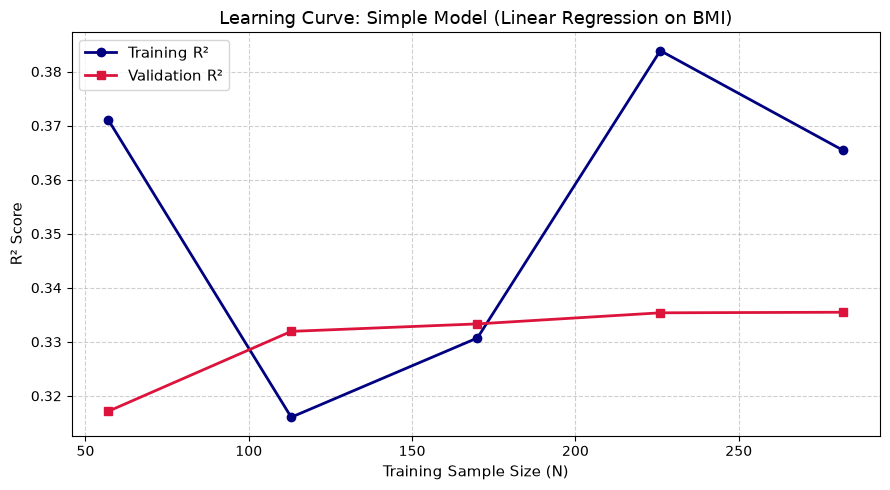

In [18]:
# Plot 3: Simple Model Learning Curve (Linear Regression on BMI)
plt.figure(figsize=(9, 5))
plt.plot(lc_simple['train_size'], lc_simple['mean_train_R2'], marker='o', label='Training R²', color='navy', linewidth=2)
plt.plot(lc_simple['train_size'], lc_simple['mean_val_R2'], marker='s', label='Validation R²', color='crimson', linewidth=2)
plt.title('Learning Curve: Simple Model (Linear Regression on BMI)', fontsize=13)
plt.xlabel('Training Sample Size (N)', fontsize=11)
plt.ylabel('R² Score', fontsize=11)
plt.legend(fontsize=11)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

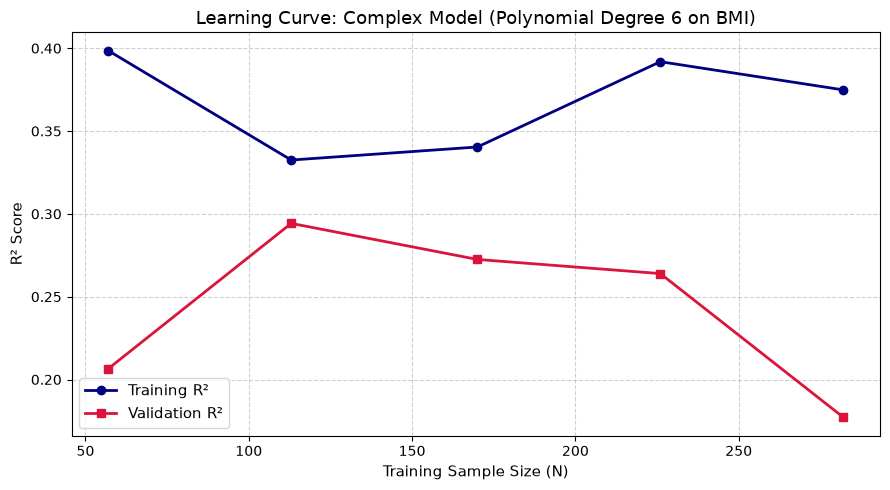

In [19]:
# Plot 4: Complex Model Learning Curve (Polynomial Degree 6 on BMI)
plt.figure(figsize=(9, 5))
plt.plot(lc_complex['train_size'], lc_complex['mean_train_R2'], marker='o', label='Training R²', color='navy', linewidth=2)
plt.plot(lc_complex['train_size'], lc_complex['mean_val_R2'], marker='s', label='Validation R²', color='crimson', linewidth=2)
plt.title('Learning Curve: Complex Model (Polynomial Degree 6 on BMI)', fontsize=13)
plt.xlabel('Training Sample Size (N)', fontsize=11)
plt.ylabel('R² Score', fontsize=11)
plt.legend(fontsize=11)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

In [20]:
# Learning Curve Diagnosis Summary Table
lc_diagnosis_df = pd.DataFrame([
    {
        'Model': 'Linear BMI (Degree 1)',
        'Final_Train_R2': lc_simple.iloc[-1]['mean_train_R2'],
        'Final_Validation_R2': lc_simple.iloc[-1]['mean_val_R2'],
        'Final_Gap': lc_simple.iloc[-1]['gap'],
        'Observed_Diagnosis': 'Limited flexibility / high-bias tendency; curves converge quickly with a small gap'
    },
    {
        'Model': 'Polynomial BMI (Degree 6)',
        'Final_Train_R2': lc_complex.iloc[-1]['mean_train_R2'],
        'Final_Validation_R2': lc_complex.iloc[-1]['mean_val_R2'],
        'Final_Gap': lc_complex.iloc[-1]['gap'],
        'Observed_Diagnosis': 'Higher variance tendency / overfitting at smaller sample sizes; persistent generalization gap'
    }
])

print("=== Learning Curve Diagnosis Table ===")
print(lc_diagnosis_df.to_string(index=False))

=== Learning Curve Diagnosis Table ===
                    Model  Final_Train_R2  Final_Validation_R2  Final_Gap                                                                            Observed_Diagnosis
    Linear BMI (Degree 1)        0.365414             0.335474   0.029940            Limited flexibility / high-bias tendency; curves converge quickly with a small gap
Polynomial BMI (Degree 6)        0.374856             0.177225   0.197631 Higher variance tendency / overfitting at smaller sample sizes; persistent generalization gap


## 20. Linking Learning Curves to Model Tuning

Learning curves provide practical diagnostic insight before committing to model adjustments:
1. **Is the model too simple (High Bias)?**
   If Training and Validation curves converge rapidly to an unsatisfactory performance plateau with a small gap, the model has limited flexibility. Adding more observations of the same type will not noticeably improve performance.
2. **Is the model too sensitive (High Variance / Overfitting)?**
   If there is a substantial gap between high Training performance and lower Validation performance, the model is sensitive to training fluctuations.
3. **Would more data help?**
   If the validation curve is still sloping upward at the maximum available training size, gathering more data could help narrow the gap.

### Transition: Strategies for Controlling Overfitting
When high variance / overfitting is detected, standard machine learning strategies include:
- Choosing a simpler model hypothesis space
- Collecting more training observations
- Feature selection to eliminate redundant predictors
- Dimensionality reduction (such as PCA)
- Early stopping during iterative optimization
- **Regularization** (penalizing large coefficients via Ridge, Lasso, and ElasticNet)

*These strategies will be investigated in subsequent lesson steps. All model selection decisions remain strictly governed by Cross Validation, with the Test Set held untouched.*

In [21]:
# Programmatic Step 2 Verification Cell
assert len(train_idx) == 353, "Train size must remain 353"
assert len(test_idx) == 89, "Test size must remain 89"
assert np.array_equal(X_raw_train.index, X_scaled_train.index), "Split indices must remain synchronized"
assert list(complexity_results['degree']) == [1, 2, 3, 4, 6, 8, 10], "Degrees tested must be exactly 1, 2, 3, 4, 6, 8, 10"
assert complexity_results['generated_feature_count'].tolist() == [1, 2, 3, 4, 6, 8, 10], "Feature counts must match degree for 1D BMI"
assert multi_poly_df['Degree'].tolist() == [1, 2, 3], "All-feature polynomial must stop at degree 3"
assert multi_poly_df['Generated_Features'].tolist() == [10, 65, 285], "All-feature counts must be 10, 65, 285"
assert len(lc_simple) == 5, "Simple learning curve must have 5 evaluation points"
assert len(lc_complex) == 5, "Complex learning curve must have 5 evaluation points"
assert 'X_scaled_test' not in globals() or 'test_score' not in globals(), "Test set must remain untouched"

print("=== Step 2 Verification Complete: All Empirical Checks Passed ===")

=== Step 2 Verification Complete: All Empirical Checks Passed ===


In [22]:
# Final Programmatic Lesson Coverage Report
print("=== Final Programmatic Checklist Status ===")
print(f"Checked:   {checked_count} / {total_count} ({checked_count / total_count * 100:.1f}%)")
print(f"Unchecked: {unchecked_count} / {total_count}")
for item, checked in checklist_items:
    if checked:
        print(f"  [x] {item}")

=== Final Programmatic Checklist Status ===
Checked:   14 / 63 (22.2%)
Unchecked: 49 / 63
  [x] Parameters vs Hyperparameters
  [x] Model Tuning stage
  [x] Train / Validation / Test separation
  [x] Cross Validation
  [x] Model Complexity
  [x] Polynomial Features
  [x] Underfitting
  [x] Overfitting
  [x] Bias
  [x] Variance
  [x] Bias-Variance Tradeoff
  [x] Irreducible Error
  [x] Training vs Validation Error
  [x] Learning Curves
